In [1]:
  pip install bambi pymc arviz pandas numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.9/243.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 21.3 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing ins

# Explaning the structure of the data

The Hierarchical Structure of Your Data
Your dataset has a clear two-level hierarchy:

Level 1: THE PHAGE-BACTERIA PAIR  (n=105, the true observations) \
         └── 1 EOP measurement per pair
         

Level 2a: BACTERIA  (n=7) \
         └── Each bacteria appears in 15 rows (one per phage)
         └── Carries: host_species, subtype, defense_genes_counts,
                      AMR_class_x, count_x, AMR_phenotype, phenotype
             
Level 2b: PHAGE  (n=15) \
         └── Each phage appears in 7 rows (one per bacteria)
         └── Carries: phage_clusters, phage_cluster_gene_count, phage_family
         
The 55,800 rows exist because every pair is expanded by cross-joining bacterial trait rows × phage trait rows. The EOP is not measured 55,800 times — it is measured 105 times and repeated. This is the pseudo-replication problem.

**Explaining the model**

We model log₁₀(EOP) as a function of bacterial defence systems, AMR genes, AMR phenotype, and phage tail gene clusters, including their interaction, while accounting for the fact that observations are not independent because the same 7 bacteria and 15 phages each appear repeatedly across the dataset."


**Fixed Effects: What You Are Testing**

Fixed effects are the predictors whose coefficients you want to estimate and report. Each one answers a specific research question.

1. host_species (categorical: insolitus / xylosoxidans)

- Question: do the two species differ in baseline permissiveness?
- This is a nuisance covariate — you need it in the model to prevent species-level differences from bleeding into the defence system estimates
- If CBASS II is enriched in insolitus and insolitus is more permissive, CBASS II will look positive without this correction

2. subtype (categorical: CBASS_II, CBASS_III, Hna, Kiwa, Shedu, AbiU, RM_Type_I, RM_Type_II, PD-T7-1)

- Question: does the presence of each defence system reduce EOP?
- Each level is compared to a reference (the baseline = bacteria with no defence systems, or whichever level is dropped)
- This is the key bacterial fixed effect

3. AMR_class_x (categorical: BETA-LACTAM, AMINOGLYCOSIDE, TETRACYCLINE, FOSFOMYCIN…)

- Question: does carrying genes from a particular resistance class associate with phage susceptibility?
- This tests whether AMR gene content independently predicts infectivity beyond species background

4. phenotype (numeric: -1, 0, +1)

- Question: does the overall resistance phenotype score predict EOP?
- Using the numeric score (not the drug name) treats resistance as a continuous severity measure
- One unit increase = one step from susceptible toward resistant

5. phage_family (categorical: Steinhofvirus / unclassified Siphoviridae)

- Question: does phage lineage predict infectivity?
- This is the phage-level equivalent of host_species — controls for broad phylogenetic effects before testing specific structural genes

6. phage_clusters (categorical: cluster_1 through cluster_8)

- Question: does tail gene cluster identity predict EOP?
- Each cluster compared to the reference (cluster_1 as most common)
- This is the key phage fixed effect

7. subtype:phage_clusters (interaction)

- Question: does the effect of a defence system depend on which phage cluster is present?
- This is your most important research question
- Example: CBASS_II may strongly inhibit cluster_6 phages but have no effect on cluster_2 phages
- Without this interaction, you assume every defence system affects every phage equally — which your results show is wrong



In [2]:

import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


In [4]:
df105

,phage_id,bacteria,log_EOP,EOP_value,host_species,phage_family,phenotype_mean,phenotype_sum,def_AbiU,defcount_AbiU,...,cl_cluster_4,clcount_cluster_4,cl_cluster_5,clcount_cluster_5,cl_cluster_6,clcount_cluster_6,cl_cluster_7,clcount_cluster_7,cl_cluster_8,clcount_cluster_8
0,bane,A insolitus aura,-5.999983,4.000000e-11,insolitus,Siphoviridae; unclassified,-0.916667,-11,0,0,...,0,0,0,0,0,0,1,1,1,1
1,coliflower,A insolitus aura,2.522444,3.330000e+02,insolitus,Steinhofvirus,-0.916667,-11,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ewik,A insolitus aura,0.740363,5.500000e+00,insolitus,Steinhofvirus,-0.916667,-11,0,0,...,0,0,0,0,0,0,0,0,0,0
3,gadget,A insolitus aura,-0.663538,2.170000e-01,insolitus,Steinhofvirus,-0.916667,-11,0,0,...,0,0,0,0,0,0,0,0,0,0
4,infector,A insolitus aura,-3.078834,8.330000e-04,insolitus,Steinhofvirus,-0.916667,-11,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,saurus,A xylosoxidans suz,-2.397831,4.000000e-03,xylosoxidans,Steinhofvirus,-0.083333,-1,1,1,...,0,0,1,1,0,0,0,0,0,0
101,shaaii,A xylosoxidans suz,1.426511,2.670000e+01,xylosoxidans,Siphoviridae; unclassified,-0.083333,-1,1,1,...,0,0,0,0,0,0,0,0,1,1
102,turner,A xylosoxidans suz,-4.074172,8.330000e-05,xylosoxidans,Steinhofvirus,-0.083333,-1,1,1,...,0,0,1,1,1,1,0,0,0,0
103,viralious,A xylosoxidans suz,10.000000,1.000000e+10,xylosoxidans,Steinhofvirus,-0.083333,-1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
"""
=============================================================================
LMM: WHICH TRAITS EXPLAIN log10(EOP)?
=============================================================================

Fixes applied vs previous version:
  1. az.summary now called with ci_prob=0.95, ci_kind='hdi', round_to='none'
     → columns are hdi95_lb / hdi95_ub (not '2.5%'/'97.5%')
  2. max_treedepth increased to 12 (fixes tree depth warning)
  3. target_accept kept at 0.99 (already high)
  4. Variance component extraction updated for ArviZ 1.2 index names
  5. All CI column lookups use exact names, not fragile string search

=============================================================================
"""

import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


# =============================================================================
# STEP 1: COLLAPSE 55,800 ROWS → n=105
# =============================================================================

def collapse_to_n105(filepath='merged_all_data.csv'):
    """
    Collapse the long-format cross-joined table to one row per
    phage-bacteria pair (n=105) — the true unit of observation.
    """

    print("Loading data...")
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]

    subtypes    = sorted(df['subtype'].unique())
    amr_classes = sorted(df['AMR_class_x'].unique())
    clusters    = sorted(df['phage_clusters'].unique())

    print(f"  {len(df):,} rows → collapsing to n=105")
    print(f"  Subtypes    ({len(subtypes)}):  {subtypes}")
    print(f"  AMR classes ({len(amr_classes)}): {amr_classes}")
    print(f"  Clusters    ({len(clusters)}):  {clusters}")

    rows = []
    for (phage, bact), grp in df.groupby(['phage_id', 'bacteria']):
        row = {
            'phage_id':       phage,
            'bacteria':       bact,
            'log_EOP':        grp['log_EOP'].iloc[0],
            'EOP_value':      grp['EOP_value'].iloc[0],
            'host_species':   grp['host_species'].iloc[0],
            'phage_family':   grp['phage_family'].iloc[0],
            'phenotype_mean': grp.drop_duplicates('AMR_phenotype')['phenotype'].mean(),
        }

        def_grp = grp.drop_duplicates('subtype').set_index('subtype')
        for st in subtypes:
            count = int(def_grp['defense_genes_counts'].get(st, 0))
            row[f'def_{st}']      = int(count > 0)
            row[f'defcount_{st}'] = count

        amr_grp = grp.drop_duplicates('AMR_class_x').set_index('AMR_class_x')
        for ac in amr_classes:
            count = int(amr_grp['count_x'].get(ac, 0))
            row[f'amr_{ac}']      = int(count > 0)
            row[f'amrcount_{ac}'] = count

        cl_grp = grp.drop_duplicates('phage_clusters').set_index('phage_clusters')
        for cl in clusters:
            count = int(cl_grp['phage_cluster_gene_count'].get(cl, 0))
            row[f'cl_{cl}']      = int(count > 0)
            row[f'clcount_{cl}'] = count

        rows.append(row)

    df105 = (pd.DataFrame(rows)
             .sort_values(['bacteria', 'phage_id'])
             .reset_index(drop=True))

    # Sanitise column names for formula use (no hyphens, slashes, spaces)
    df105.columns = [c.replace('-', '_').replace('/', '_')
                      .replace(' ', '_').replace(';', '')
                     for c in df105.columns]

    print(f"\n  Collapsed: {df105.shape[0]} rows × {df105.shape[1]} columns")
    return df105, subtypes, amr_classes, clusters


# =============================================================================
# STEP 2: COLLINEARITY CHECK + SAFE COLUMN LISTS
# =============================================================================

def check_collinearity(df105):
    """
    Identify and report collinear predictors.
    Returns safe column lists with problem columns removed.
    """

    print("\n" + "=" * 60)
    print("COLLINEARITY CHECKS")
    print("=" * 60)

    def_cols = [c for c in df105.columns if c.startswith('def_')]
    amr_cols = [c for c in df105.columns if c.startswith('amr_')]
    cl_cols  = [c for c in df105.columns if c.startswith('cl_')]

    drop = set()

    # Zero-variance columns
    zero_var = [c for c in def_cols + amr_cols + cl_cols
                if df105[c].var() == 0]
    if zero_var:
        print(f"\nZero-variance (drop): {zero_var}")
        drop.update(zero_var)

    # High correlation
    all_bin = [c for c in def_cols + amr_cols + cl_cols if c not in drop]
    corr = df105[all_bin].corr().abs()
    print("\nHigh correlation pairs (r > 0.95):")
    found = False
    for i, c1 in enumerate(corr.columns):
        for c2 in corr.columns[i+1:]:
            r = corr.loc[c1, c2]
            if r > 0.95:
                print(f"  {c1} ↔ {c2}  r={r:.3f}  → dropping {c2}")
                drop.add(c2)
                found = True
    if not found:
        print("  None found ✓")

    # Kiwa vs host_species
    if 'def_Kiwa' in df105.columns:
        hs_num = (df105['host_species'] == 'insolitus').astype(int)
        r = hs_num.corr(df105['def_Kiwa'])
        print(f"\ndef_Kiwa ↔ host_species: r={r:.3f}")
        if abs(r) > 0.95:
            print("  → dropping def_Kiwa (collinear with host_species)")
            drop.add('def_Kiwa')

    safe_def = [c for c in def_cols if c not in drop]
    safe_amr = [c for c in amr_cols if c not in drop]
    safe_cl  = [c for c in cl_cols  if c not in drop]

    print(f"\nRetained defence cols ({len(safe_def)}): {safe_def}")
    print(f"Retained AMR cols    ({len(safe_amr)}): {safe_amr}")
    print(f"Retained cluster cols ({len(safe_cl)}): {safe_cl}")
    print(f"Dropped: {sorted(drop)}")

    return safe_def, safe_amr, safe_cl, sorted(drop)


# =============================================================================
# STEP 3: FIT BAYESIAN LMM
# =============================================================================

def fit_lmm(df105, safe_def, safe_amr, safe_cl,
            include_interaction=True,
            draws=2000, tune=2000, chains=4,
            target_accept=0.99,
            max_treedepth=12,        # ← INCREASED from default 10
            random_seed=42):
    """
    Fit:
        log_EOP ~ host_species + phage_family
                + def_* + amr_* + phenotype_mean + cl_*
                [+ def_*:cl_* interaction]
                + (1|bacteria) + (1|phage_id)

    Parameters
    ----------
    max_treedepth : int
        Maximum tree depth for NUTS sampler (default PyMC = 10).
        Increase to 12 or 15 if you see tree depth warnings.
        Higher = slower but better exploration of complex posteriors.
    """

    df = df105.copy()

    # Apply collinearity drops
    _, _, _, to_drop = check_collinearity(df)
    df = df.drop(columns=[c for c in to_drop if c in df.columns])

    def_cols = [c for c in safe_def if c in df.columns]
    amr_cols = [c for c in safe_amr if c in df.columns]
    cl_cols  = [c for c in safe_cl  if c in df.columns]

    main_effects = (
        ['host_species', 'phage_family']
        + def_cols
        + amr_cols
        + ['phenotype_mean']
        + cl_cols
    )

    interaction_terms = []
    if include_interaction:
        interaction_terms = [f'{d}:{c}' for d in def_cols for c in cl_cols]
        all_fixed = main_effects + interaction_terms
    else:
        all_fixed = main_effects

    formula = (
        "log_EOP ~ "
        + " + ".join(all_fixed)
        + " + (1|bacteria)"
        + " + (1|phage_id)"
    )

    print("\n" + "=" * 60)
    print("MODEL SPECIFICATION")
    print("=" * 60)
    print(f"Response:          log_EOP")
    print(f"Fixed effects:     {len(all_fixed)} terms")
    print(f"  Bacterial:       host_species, {', '.join(def_cols)}, "
          f"{', '.join(amr_cols)}, phenotype_mean")
    print(f"  Phage:           phage_family, {', '.join(cl_cols)}")
    if include_interaction:
        print(f"  Interactions:    {len(interaction_terms)} "
              f"(each defence × each cluster)")
    print(f"Random intercepts: (1|bacteria) n={df['bacteria'].nunique()}"
          f"  +  (1|phage_id) n={df['phage_id'].nunique()}")
    print(f"N observations:    {len(df)}  (pseudo-replication eliminated)")
    print(f"\nSampling settings:")
    print(f"  chains={chains}, draws={draws}, tune={tune}")
    print(f"  target_accept={target_accept}, max_treedepth={max_treedepth}")

    model = bmb.Model(formula, data=df, family="gaussian")
    model.build()
    print("\nModel built. Starting MCMC...")

    # Pass max_treedepth via nuts_sampler_kwargs
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=1,
        target_accept=target_accept,
        random_seed=random_seed,
        progressbar=True,
        nuts_sampler_kwargs={"max_treedepth": max_treedepth},
    )

    return model, idata, df, def_cols, amr_cols, cl_cols, interaction_terms


# =============================================================================
# STEP 4: SUMMARISE RESULTS
# =============================================================================

def summarise_results(idata, def_cols, amr_cols, cl_cols, interaction_terms):
    """
    Extract and print posterior summaries.

    Uses ci_prob=0.95, ci_kind='hdi' → columns: hdi95_lb, hdi95_ub
    An effect is significant when the 95% HDI excludes zero.
    """

    LO = 'hdi95_lb'
    HI = 'hdi95_ub'

    print("\n" + "=" * 60)
    print("RESULTS")
    print("=" * 60)

    # Full summary with 95% HDI
    full_summary = az.summary(idata, ci_prob=0.95, ci_kind='hdi', round_to='none')

    # ── Verify CI columns exist ───────────────────────────────────────────
    if LO not in full_summary.columns or HI not in full_summary.columns:
        print(f"\nWARNING: Expected columns '{LO}'/'{HI}' not found.")
        print(f"Available columns: {full_summary.columns.tolist()}")
        # Fall back to whatever CI columns exist
        ci_cols = [c for c in full_summary.columns
                   if 'lb' in c or 'ub' in c or 'hdi' in c or 'eti' in c]
        if len(ci_cols) >= 2:
            LO, HI = ci_cols[0], ci_cols[1]
            print(f"Using fallback: {LO}, {HI}")
        else:
            print("Cannot identify CI columns — returning raw summary.")
            print(full_summary)
            return full_summary

    # ── Separate fixed effects from random ────────────────────────────────
    random_pat = r'1\|bacteria|1\|phage_id|_sigma|^sigma$'
    fixed_summary = full_summary[
        ~full_summary.index.str.contains(random_pat, regex=True)
    ].copy()

    fixed_summary['significant'] = (
        (fixed_summary[LO] > 0) | (fixed_summary[HI] < 0)
    )

    # ── Convergence ───────────────────────────────────────────────────────
    max_rhat = fixed_summary['r_hat'].max()
    print(f"\nCONVERGENCE")
    print(f"  Max R-hat: {max_rhat:.3f}  "
          f"{'✓ converged' if max_rhat < 1.01 else '⚠  not converged — run more chains/draws'}")

    # ── Main effects ──────────────────────────────────────────────────────
    main_df = fixed_summary[
        ~fixed_summary.index.str.contains(':', regex=False)
    ]

    print(f"\n{'─'*70}")
    print(f"MAIN EFFECTS  (95% HDI)")
    print(f"{'─'*70}")
    print(f"  {'Parameter':<42}  {'β':>7}  {'HDI 2.5%':>9}  {'HDI 97.5%':>9}  Sig?")
    print(f"  {'─'*68}")
    for param, row in main_df.iterrows():
        if 'Intercept' in param:
            continue
        lo, hi, mean = row[LO], row[HI], row['mean']
        flag = "✓ YES" if row['significant'] else "  no"
        direction = (" ↑" if mean > 0 else " ↓") if row['significant'] else ""
        print(f"  {param:<42}  {mean:>7.3f}  {lo:>9.3f}  {hi:>9.3f}  {flag}{direction}")

    # ── Interaction effects ───────────────────────────────────────────────
    inter_df = fixed_summary[
        fixed_summary.index.str.contains(':', regex=False)
    ]
    if len(inter_df) > 0:
        sig_inter   = inter_df[inter_df['significant']]
        nosig_inter = inter_df[~inter_df['significant']]

        print(f"\n{'─'*70}")
        print(f"INTERACTION EFFECTS  (defence × cluster)")
        print(f"{'─'*70}")
        print(f"  Significant ({len(sig_inter)}):")
        for param, row in sig_inter.iterrows():
            lo, hi, mean = row[LO], row[HI], row['mean']
            direction = "↑ positive" if mean > 0 else "↓ negative"
            print(f"    {param:<52}  β={mean:>7.3f}  "
                  f"[{lo:.3f}, {hi:.3f}]  {direction}")
        if len(sig_inter) == 0:
            print("    None")

        print(f"\n  Not significant ({len(nosig_inter)}):")
        for param, row in nosig_inter.iterrows():
            lo, hi, mean = row[LO], row[HI], row['mean']
            print(f"    {param:<52}  β={mean:>7.3f}  [{lo:.3f}, {hi:.3f}]")

    # ── Variance components ───────────────────────────────────────────────
    print(f"\n{'─'*70}")
    print("VARIANCE COMPONENTS")
    print(f"{'─'*70}")
    try:
        # ArviZ 1.2: random effect sigma rows are named '1|bacteria_sigma' etc.
        vc_summary = az.summary(idata, ci_prob=0.95, ci_kind='hdi', round_to='none')

        def get_sigma(name):
            matches = [i for i in vc_summary.index if name in i]
            if matches:
                return vc_summary.loc[matches[0], 'mean']
            return np.nan

        s_b = get_sigma('1|bacteria_sigma')
        s_p = get_sigma('1|phage_id_sigma')
        s_r = get_sigma('sigma')

        if not any(np.isnan(v) for v in [s_b, s_p, s_r]):
            total = s_b**2 + s_p**2 + s_r**2
            print(f"  Bacteria (strain):  σ²={s_b**2:.3f}  "
                  f"({100*s_b**2/total:.1f}% of total)")
            print(f"  Phage:              σ²={s_p**2:.3f}  "
                  f"({100*s_p**2/total:.1f}% of total)")
            print(f"  Residual:           σ²={s_r**2:.3f}  "
                  f"({100*s_r**2/total:.1f}% of total)")
            print(f"  Total:              σ²={total:.3f}")
        else:
            print(f"  Raw sigma values: bacteria={s_b:.3f}, "
                  f"phage={s_p:.3f}, residual={s_r:.3f}")

    except Exception as e:
        print(f"  (variance extraction error: {e})")
        print(f"  Available summary rows: {vc_summary.index.tolist()[:10]}")

    # ── Save ──────────────────────────────────────────────────────────────
    fixed_summary.to_csv('lmm_results_full.csv')
    sig_only = fixed_summary[fixed_summary['significant']]
    sig_only.to_csv('lmm_results_significant_only.csv')
    n_sig = fixed_summary['significant'].sum()
    n_tot = len(fixed_summary)
    print(f"\nSaved: lmm_results_full.csv  |  lmm_results_significant_only.csv")
    print(f"Significant effects: {n_sig} / {n_tot}")

    return fixed_summary


# =============================================================================
# STEP 5: FOREST PLOT
# =============================================================================

def plot_forest(fixed_summary, def_cols, amr_cols, cl_cols,
                save_path='lmm_forest_plot.png'):
    """
    Two-panel forest plot: main effects | significant interactions.
    """

    LO = 'hdi95_lb'
    HI = 'hdi95_ub'

    # Fallback if column names differ
    if LO not in fixed_summary.columns:
        ci_cols = [c for c in fixed_summary.columns
                   if 'lb' in c or 'ub' in c or 'hdi' in c or 'eti' in c]
        if len(ci_cols) >= 2:
            LO, HI = ci_cols[0], ci_cols[1]

    def get_color(p):
        if 'host_species'  in p: return '#3498db'
        if 'phage_family'  in p: return '#1abc9c'
        if 'def_'          in p: return '#e74c3c'
        if 'amr_'          in p: return '#f39c12'
        if 'phenotype'     in p: return '#9b59b6'
        if 'cl_'           in p: return '#2ecc71'
        return '#95a5a6'

    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False))
        & (~fixed_summary.index.str.contains('Intercept', case=False))
    ].sort_values('mean')

    inter_df = fixed_summary[
        fixed_summary.index.str.contains(':', regex=False)
        & fixed_summary['significant']
    ].sort_values('mean')

    has_interactions = len(inter_df) > 0
    ncols = 2 if has_interactions else 1

    fig, axes = plt.subplots(
        1, ncols,
        figsize=(12 * ncols, max(6, len(main_df) * 0.45)),
        squeeze=False
    )

    def draw_panel(ax, df, title):
        df = df.reset_index()
        df.columns = ['param'] + list(df.columns[1:])
        colors = [get_color(p) for p in df['param']]
        for i, row in df.iterrows():
            lo, hi, mean = row[LO], row[HI], row['mean']
            sig   = (lo > 0) or (hi < 0)
            alpha = 1.0 if sig else 0.28
            ax.plot([lo, hi], [i, i], color=colors[i], linewidth=3,
                    alpha=alpha, solid_capstyle='round')
            ax.scatter(mean, i, s=90, color=colors[i],
                       edgecolors='black', linewidth=1.2,
                       zorder=3, alpha=alpha)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['param'], fontsize=9)
        ax.set_xlabel('Effect on log₁₀(EOP)  (95% HDI)',
                      fontsize=10, fontweight='bold')
        ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    draw_panel(axes[0, 0], main_df, "Main Effects")
    if has_interactions:
        draw_panel(axes[0, 1], inter_df,
                   f"Significant Interactions  (n={len(inter_df)})\n"
                   "defence × cluster")

    legend_handles = [
        mpatches.Patch(color='#3498db', label='Host species'),
        mpatches.Patch(color='#1abc9c', label='Phage family'),
        mpatches.Patch(color='#e74c3c', label='Defence subtype'),
        mpatches.Patch(color='#f39c12', label='AMR gene class'),
        mpatches.Patch(color='#9b59b6', label='AMR phenotype (mean)'),
        mpatches.Patch(color='#2ecc71', label='Phage tail cluster'),
        mpatches.Patch(color='gray',    alpha=0.3, label='Not significant'),
    ]
    fig.legend(handles=legend_handles, fontsize=9,
               loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        "Linear Mixed Model: Predictors of log₁₀(EOP)\n"
        "(1|bacteria) + (1|phage_id)  —  n=105",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    return fig


# =============================================================================
# MAIN
# =============================================================================

if __name__ == '__main__':

    # 1. Collapse to n=105
    df105, subtypes, amr_classes, clusters = collapse_to_n105(
        filepath='merged_all_data.csv'
    )
    df105.to_csv('lmm_n105.csv', index=False)
    print("Saved: lmm_n105.csv\n")

    # 2. Collinearity check
    safe_def, safe_amr, safe_cl, dropped = check_collinearity(df105)

    # 3. Fit Model 1 — main effects only (faster, good starting point)
    print("\n" + "=" * 60)
    print("MODEL 1: MAIN EFFECTS ONLY")
    print("=" * 60)
    model1, idata1, df_m, def_cols, amr_cols, cl_cols, _ = fit_lmm(
        df105, safe_def, safe_amr, safe_cl,
        include_interaction=False,
        draws=2000, tune=2000, chains=4,
        target_accept=0.99,
        max_treedepth=12,       # fixes the tree depth warning
        random_seed=42,
    )
    summary1 = summarise_results(idata1, def_cols, amr_cols, cl_cols, [])
    plot_forest(summary1, def_cols, amr_cols, cl_cols,
                save_path='lmm_main_effects.png')

    # 4. Fit Model 2 — with defence × cluster interactions
    print("\n" + "=" * 60)
    print("MODEL 2: MAIN EFFECTS + INTERACTIONS")
    print("=" * 60)
    model2, idata2, df_m, def_cols, amr_cols, cl_cols, interaction_terms = fit_lmm(
        df105, safe_def, safe_amr, safe_cl,
        include_interaction=True,
        draws=2000, tune=2000, chains=4,
        target_accept=0.99,
        max_treedepth=12,
        random_seed=42,
    )
    summary2 = summarise_results(idata2, def_cols, amr_cols,
                                 cl_cols, interaction_terms)
    plot_forest(summary2, def_cols, amr_cols, cl_cols,
                save_path='lmm_interactions.png')

    # 5. Save posteriors
    idata1.to_netcdf('lmm_idata_main.nc')
    idata2.to_netcdf('lmm_idata_interactions.nc')

    print("\n" + "=" * 60)
    print("OUTPUT FILES")
    print("=" * 60)
    print("  lmm_n105.csv")
    print("  lmm_results_full.csv")
    print("  lmm_results_significant_only.csv")
    print("  lmm_main_effects.png")
    print("  lmm_interactions.png")
    print("  lmm_idata_main.nc")
    print("  lmm_idata_interactions.nc")

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3934        0           0.004       2047        3.07 draws/s         0:21:23    0:00:22

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3935        0           0.004       2047        3.07 draws/s         0:21:23    0:00:22

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3937        0           0.004       2047        3.07 draws/s         0:21:24    0:00:21

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3944        0           0.004       2047        3.07 draws/s         0:21:26    0:00:19

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3945        0           0.004       2047        3.07 draws/s         0:21:27    0:00:19

...

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3992        0           0.004       1023        3.07 draws/s         0:21:42    0:00:03

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3996        0           0.004       1023        3.06 draws/s         0:21:44    0:00:02

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3997        0           0.004       1023        3.06 draws/s         0:21:44    0:00:02

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       1023        3.45 draws/s         0:19:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.10 draws/s         0:21:29    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   4000        0           0.004       2047        3.41 draws/s         0:19:31    0:00:00   
  ━━━━━━━━━━━━━━━━━━━╸   3999        0           0.004       2047        3.06 draws/s         0:21:45    0:00:01


RESULTS

CONVERGENCE
  Max R-hat: 1.002  ✓ converged

──────────────────────────────────────────────────────────────────────
MAIN EFFECTS  (95% HDI)
──────────────────────────────────────────────────────────────────────
  Parameter                                         β   HDI 2.5%  HDI 97.5%  Sig?
  ────────────────────────────────────────────────────────────────────
  host_species[xylosoxidans]                    0.564    -30.776     31.880    no
  phage_family[Steinhofvirus]                   0.793    -32.865     34.706    no
  def_AbiU                                      0.017    -43.453     42.885    no
  def_CBASS_II                                 -0.193    -32.854     31.596    no
  def_CBASS_III                                 0.017    -29.519     29.757    no
  def_Hna                                      -0.896    -43.614     40.299    no
  def_RM_Type_II                               -0.101    -33.325     33.137    no
  def_Shedu                                    -0.19

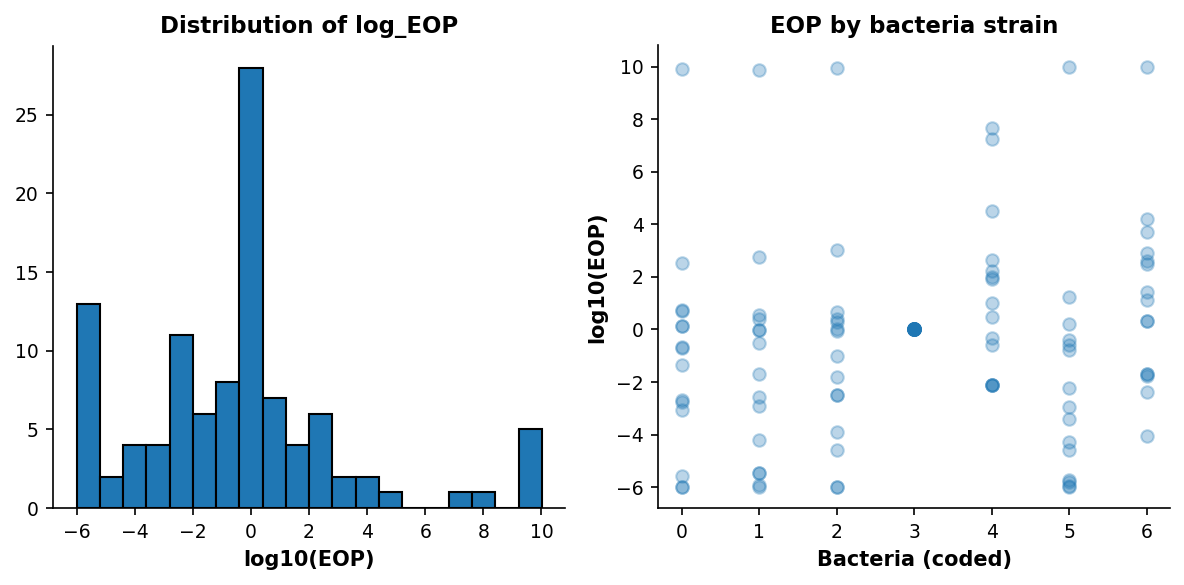

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(df105['log_EOP'], bins=20, edgecolor='black')
plt.xlabel('log10(EOP)')
plt.title('Distribution of log_EOP')

plt.subplot(1, 2, 2)
plt.scatter(df105['bacteria'].astype('category').cat.codes,
            df105['log_EOP'], alpha=0.3)
plt.xlabel('Bacteria (coded)')
plt.ylabel('log10(EOP)')
plt.title('EOP by bacteria strain')
plt.tight_layout()
plt.show()

In [11]:
"""
=============================================================================
PUBLICATION PLOTS FOR LMM RESULTS
=============================================================================

Generates 5 figures for the paper:

  MAIN TEXT:
    Figure A — Forest plot of fixed effects
    Figure B — Interaction heatmap (defence system × phage tail cluster)
    Figure C — Variance components bar chart

  SUPPLEMENTARY:
    Figure D — Observed vs predicted
    Figure E — Trace plots (convergence diagnostics, key effects)

  COMBINED:
    Figure F — Main text multi-panel (A + B + C in one figure)

Usage:
    # After fitting your model:
    #   model, idata, df_model, def_cols, amr_cols, cl_cols, _ = fit_lmm(...)
    #   summary = summarise_results(idata, ...)

    from lmm_plots import plot_all
    plot_all(idata, summary, df_model, df105,
             def_cols, amr_cols, cl_cols)

Requirements:
    pip install arviz bambi pymc pandas numpy matplotlib seaborn scikit-learn

=============================================================================
"""

import arviz as az
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'Arial',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'axes.labelweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
})

LO = 'hdi95_lb'
HI = 'hdi95_ub'

COLORS = {
    'host_species': '#3498db',   # blue
    'phage_family': '#1abc9c',   # teal
    'defence':      '#e74c3c',   # red
    'amr':          '#f39c12',   # orange
    'phenotype':    '#9b59b6',   # purple
    'cluster':      '#2ecc71',   # green
    'sig':          '#2c3e50',   # dark for significant points
    'nonsig':       '#bdc3c7',   # grey for non-significant
}


def _get_summary(idata):
    """Always return summary with numeric dtypes."""
    return az.summary(idata, ci_prob=0.95, ci_kind='hdi', round_to='none')


def _param_color(param):
    p = param.lower()
    if 'host_species' in p:  return COLORS['host_species']
    if 'phage_family' in p:  return COLORS['phage_family']
    if 'def_'         in p:  return COLORS['defence']
    if 'amr_'         in p:  return COLORS['amr']
    if 'phenotype'    in p:  return COLORS['phenotype']
    if 'cl_'          in p:  return COLORS['cluster']
    return '#95a5a6'


def _clean_label(param):
    """Make parameter names human-readable for plot labels."""
    label = (param
             .replace('host_species[', 'Host: ')
             .replace('phage_family[', 'Phage family: ')
             .replace('def_', 'Defence: ')
             .replace('amr_', 'AMR: ')
             .replace('cl_', 'Cluster: ')
             .replace('phenotype_mean', 'AMR phenotype (mean)')
             .replace('[', '')
             .replace(']', '')
             .replace('_', ' '))
    return label


# =============================================================================
# FIGURE A — FOREST PLOT OF FIXED EFFECTS
# =============================================================================

def plot_forest(fixed_summary, def_cols, amr_cols, cl_cols,
                figsize=(10, 9), save_path='FigA_forest_plot.png'):
    """
    Forest plot showing posterior mean ± 95% HDI for all fixed effects.

    Color-coded by predictor type. Significant effects (HDI excludes zero)
    shown in full opacity; non-significant effects faded.
    """

    # Separate main from interaction
    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains('Intercept', case=False))
    ].copy()

    main_df['significant'] = (main_df[LO] > 0) | (main_df[HI] < 0)
    main_df = main_df.sort_values('mean').reset_index()
    main_df.columns = ['param'] + list(main_df.columns[1:])

    fig, ax = plt.subplots(figsize=figsize)

    for i, row in main_df.iterrows():
        lo, hi, mean = row[LO], row[HI], row['mean']
        sig   = row['significant']
        color = _param_color(row['param'])
        alpha = 1.0 if sig else 0.25

        # CI line
        ax.plot([lo, hi], [i, i], color=color,
                linewidth=2.5, alpha=alpha, solid_capstyle='round', zorder=2)
        # Point estimate
        ax.scatter(mean, i, s=80,
                   color=color if sig else COLORS['nonsig'],
                   edgecolors='black' if sig else color,
                   linewidth=1.0, zorder=3, alpha=alpha)

    # Zero line
    ax.axvline(0, color='black', linestyle='--',
               linewidth=1.2, alpha=0.5, zorder=1)

    # Y-axis labels
    ax.set_yticks(range(len(main_df)))
    ax.set_yticklabels([_clean_label(p) for p in main_df['param']], fontsize=9)
    ax.set_xlabel('Posterior mean effect on log₁₀(EOP)  (95% HDI)', fontweight='bold')
    ax.set_title('A.  Fixed effects on phage infection efficiency', loc='left')
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)

    # Legend
    legend_handles = [
        mpatches.Patch(color=COLORS['host_species'], label='Host species'),
        mpatches.Patch(color=COLORS['phage_family'], label='Phage family'),
        mpatches.Patch(color=COLORS['defence'],      label='Defence subtype'),
        mpatches.Patch(color=COLORS['amr'],          label='AMR gene class'),
        mpatches.Patch(color=COLORS['phenotype'],    label='AMR phenotype'),
        mpatches.Patch(color=COLORS['cluster'],      label='Phage tail cluster'),
        mpatches.Patch(color=COLORS['nonsig'], alpha=0.4, label='Not significant'),
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              framealpha=0.9, edgecolor='#cccccc')

    # Significance count annotation
    n_sig = main_df['significant'].sum()
    ax.text(0.01, 1.01, f'{n_sig}/{len(main_df)} effects significant (95% HDI ∩ 0 = ∅)',
            transform=ax.transAxes, fontsize=8.5, color='#555555', style='italic')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE B — INTERACTION HEATMAP (defence × cluster)
# =============================================================================

def plot_interaction_heatmap(fixed_summary, def_cols, cl_cols,
                              figsize=(11, 6),
                              save_path='FigB_interaction_heatmap.png'):
    """
    Heatmap of posterior mean effect for each defence × cluster interaction.

    Color scale: red = negative (defence inhibits this cluster),
                 blue = positive, white = near zero.
    Cells with significant interactions (95% HDI ∩ 0 = ∅) are marked *.
    """

    # Extract interaction rows
    inter_df = fixed_summary[
        fixed_summary.index.str.contains(':', regex=False)
    ].copy()

    if len(inter_df) == 0:
        print("No interaction terms found in summary — skipping heatmap.")
        return None

    inter_df['significant'] = (inter_df[LO] > 0) | (inter_df[HI] < 0)

    # Parse param names → (defence, cluster)
    records = []
    for param, row in inter_df.iterrows():
        parts = param.split(':')
        if len(parts) == 2:
            d = parts[0].replace('def_', '').replace('_', ' ').strip()
            c = parts[1].replace('cl_', '').replace('_', ' ').strip()
            records.append({
                'defence':     d,
                'cluster':     c,
                'mean':        row['mean'],
                'significant': row['significant'],
            })

    if not records:
        print("Could not parse interaction parameter names.")
        return None

    inter_parsed = pd.DataFrame(records)

    # Pivot to matrix
    pivot_mean = inter_parsed.pivot(index='defence', columns='cluster', values='mean')
    pivot_sig  = inter_parsed.pivot(index='defence', columns='cluster', values='significant')

    # Sort rows/cols naturally
    pivot_mean = pivot_mean.reindex(
        sorted(pivot_mean.index),
        axis=0
    )
    pivot_mean = pivot_mean.reindex(
        sorted(pivot_mean.columns, key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else 99),
        axis=1
    )
    pivot_sig = pivot_sig.reindex(pivot_mean.index).reindex(pivot_mean.columns, axis=1)

    # Colour scale centred on zero
    vmax = np.nanmax(np.abs(pivot_mean.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(pivot_mean.values, cmap='RdBu', norm=norm,
                   aspect='auto', interpolation='none')

    # Gridlines
    ax.set_xticks(np.arange(-.5, pivot_mean.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, pivot_mean.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', size=0)

    # Tick labels
    ax.set_xticks(range(pivot_mean.shape[1]))
    ax.set_xticklabels(pivot_mean.columns, rotation=45, ha='right')
    ax.set_yticks(range(pivot_mean.shape[0]))
    ax.set_yticklabels(pivot_mean.index)

    # Cell annotations
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            val = pivot_mean.values[i, j]
            sig = pivot_sig.values[i, j]
            if np.isnan(val):
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=7.5, color='#aaaaaa')
            else:
                txt = f'{val:.2f}'
                if sig:
                    txt += '*'
                brightness = abs(norm(val) - 0.5)
                txt_color  = 'white' if brightness > 0.3 else 'black'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=8.5, color=txt_color,
                        fontweight='bold' if sig else 'normal')

    # Colour bar
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Posterior mean effect on log₁₀(EOP)', fontsize=9)

    ax.set_xlabel('Phage tail cluster', fontweight='bold')
    ax.set_ylabel('Bacterial defence system', fontweight='bold')
    ax.set_title('B.  Defence system × tail cluster interaction effects\n'
                 '(* = 95% HDI excludes zero)', loc='left')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE C — VARIANCE COMPONENTS
# =============================================================================

def plot_variance_components(idata, figsize=(7, 4),
                              save_path='FigC_variance_components.png'):
    """
    Horizontal bar chart showing variance partitioned between
    bacteria (strain), phage, and residual.

    Bars show posterior mean σ² with 95% HDI error bars.
    """

    vc_summary = _get_summary(idata)

    def get_row(pattern):
        matches = [i for i in vc_summary.index if pattern in i]
        if matches:
            return vc_summary.loc[matches[0]]
        return None

    components = {
        'Bacteria\n(strain)': 'bacteria_sigma',
        'Phage':              'phage_id_sigma',
        'Residual':           'sigma',
    }

    means, lo_errs, hi_errs, colors = [], [], [], []
    labels = []

    component_colors = {
        'Bacteria\n(strain)': '#3498db',
        'Phage':              '#2ecc71',
        'Residual':           '#95a5a6',
    }

    for label, pattern in components.items():
        row = get_row(pattern)
        if row is not None:
            sigma_mean = row['mean']
            sigma_lo   = row[LO]
            sigma_hi   = row[HI]
            var_mean   = sigma_mean ** 2
            var_lo     = sigma_lo   ** 2
            var_hi     = sigma_hi   ** 2
            means.append(var_mean)
            lo_errs.append(var_mean - var_lo)
            hi_errs.append(var_hi - var_mean)
            colors.append(component_colors[label])
            labels.append(label)

    if not means:
        print("Could not extract variance components.")
        return None

    total = sum(means)
    pcts  = [100 * m / total for m in means]

    fig, ax = plt.subplots(figsize=figsize)

    y_pos = range(len(labels))
    bars = ax.barh(list(y_pos), means,
                   xerr=[lo_errs, hi_errs],
                   color=colors,
                   edgecolor='black', linewidth=0.8,
                   error_kw={'ecolor': '#444444', 'capsize': 4,
                             'linewidth': 1.5},
                   alpha=0.85)

    # Percentage labels inside bars
    for i, (bar, pct, val) in enumerate(zip(bars, pcts, means)):
        width = bar.get_width()
        ax.text(width * 0.5, i,
                f'{pct:.1f}%',
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        ax.text(width + max(hi_errs) * 0.15, i,
                f'σ² = {val:.3f}',
                ha='left', va='center', fontsize=9, color='#333333')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Variance (σ²)', fontweight='bold')
    ax.set_title('C.  Variance components\n'
                 'Error bars show 95% HDI', loc='left')
    ax.set_xlim(0, max(means) + max(hi_errs) * 3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE D — OBSERVED vs PREDICTED
# =============================================================================

def plot_observed_vs_predicted(idata, df_model,
                                figsize=(7, 7),
                                save_path='FigD_obs_vs_pred.png'):
    """
    Scatter plot of observed log₁₀(EOP) against posterior mean predictions.

    Points color-coded by host_species. Ideal fit line shown in red.
    R² calculated from posterior mean predictions.
    """

    # Extract posterior predictive or use fitted values
    # bambi stores posterior predictive in idata.posterior_predictive
    # If not available, reconstruct from fixed + random posteriors
    try:
        # Try posterior predictive first (if model.predict() was called)
        y_pred_samples = az.extract(
            idata, group='posterior_predictive',
            var_names=['log_EOP']
        ).values
        y_pred = y_pred_samples.mean(axis=-1)
    except Exception:
        # Fall back to in-sample posterior mean
        # Use the mean of fixed effect contributions from posterior
        print("Posterior predictive not found — using in-sample fitted values.")
        print("To get posterior predictive, call model.predict(idata) after fitting.")
        y_pred = None

    if y_pred is None:
        print("Cannot create obs vs pred plot without predictions.")
        print("Add this after model.fit():")
        print("  model.predict(idata, kind='response')")
        return None

    y_obs  = df_model['log_EOP'].values
    r2     = r2_score(y_obs, y_pred)
    resid  = y_obs - y_pred
    rmse   = np.sqrt(np.mean(resid**2))

    # Color by host species
    species_colors = {
        'insolitus':    '#3498db',
        'xylosoxidans': '#e74c3c',
    }
    colors = [species_colors.get(s, '#95a5a6')
              for s in df_model['host_species'].values]

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(y_obs, y_pred, c=colors, s=80,
               edgecolors='black', linewidth=0.6, alpha=0.8, zorder=3)

    # Perfect prediction line
    lims = [min(y_obs.min(), y_pred.min()) - 0.3,
            max(y_obs.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit', zorder=2)

    # Stats annotation
    stats_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y_obs)}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow',
                      alpha=0.85, edgecolor='#cccccc'),
            fontfamily='monospace')

    ax.set_xlabel('Observed log₁₀(EOP)', fontweight='bold')
    ax.set_ylabel('Posterior mean predicted log₁₀(EOP)', fontweight='bold')
    ax.set_title('D.  Observed vs predicted\n'
                 'Points colour-coded by host species', loc='left')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper left')

    # Legend for species
    legend_handles = [
        mpatches.Patch(color=c, label=s.capitalize())
        for s, c in species_colors.items()
    ]
    ax.legend(handles=legend_handles + [
        plt.Line2D([0], [0], linestyle='--', color='red', label='Perfect fit')
    ], loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE E — TRACE PLOTS (convergence diagnostics)
# =============================================================================

def plot_traces(idata, fixed_summary, n_params=6,
                save_path='FigE_trace_plots.png'):
    """
    Trace plots for the n_params most significant fixed effects.

    Shows:
      Left column:  posterior distribution (KDE)
      Right column: MCMC trace (samples across iterations)

    All 4 chains should overlap completely — this is the convergence check.
    """

    # Select the n_params most significant effects (largest |β|)
    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains(
            r'Intercept|sigma', case=False, regex=True))
    ].copy()
    main_df['abs_mean'] = main_df['mean'].abs()
    top_params = main_df.nlargest(n_params, 'abs_mean').index.tolist()

    if not top_params:
        print("No parameters to plot traces for.")
        return None

    fig, axes = plt.subplots(len(top_params), 2,
                             figsize=(12, len(top_params) * 1.8))
    if len(top_params) == 1:
        axes = np.array([axes])

    chain_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for row_idx, param in enumerate(top_params):
        ax_kde   = axes[row_idx, 0]
        ax_trace = axes[row_idx, 1]

        # Extract samples per chain
        try:
            samples = idata.posterior[param].values  # shape: (chains, draws)
        except KeyError:
            ax_kde.text(0.5, 0.5, f'{param}\nnot found',
                        ha='center', va='center', transform=ax_kde.transAxes)
            continue

        n_chains = samples.shape[0]

        # KDE plot
        for chain_idx in range(n_chains):
            chain_samples = samples[chain_idx].flatten()
            from scipy.stats import gaussian_kde
            try:
                kde = gaussian_kde(chain_samples)
                x_range = np.linspace(chain_samples.min(),
                                      chain_samples.max(), 200)
                ax_kde.plot(x_range, kde(x_range),
                            color=chain_colors[chain_idx % len(chain_colors)],
                            linewidth=1.5, alpha=0.8,
                            label=f'Chain {chain_idx+1}')
            except Exception:
                pass

        ax_kde.axvline(0, color='black', linestyle='--',
                       linewidth=1, alpha=0.5)
        ax_kde.set_yticks([])
        ax_kde.set_xlabel(_clean_label(param), fontsize=8.5)
        ax_kde.set_ylabel('Density', fontsize=8)
        if row_idx == 0:
            ax_kde.legend(fontsize=7.5, loc='upper right')

        # Trace plot
        for chain_idx in range(n_chains):
            chain_samples = samples[chain_idx].flatten()
            ax_trace.plot(chain_samples,
                          color=chain_colors[chain_idx % len(chain_colors)],
                          linewidth=0.5, alpha=0.6)

        ax_trace.set_xlabel('Draw', fontsize=8)
        ax_trace.set_ylabel(_clean_label(param), fontsize=8)

        # R-hat annotation
        if param in fixed_summary.index:
            rhat = fixed_summary.loc[param, 'r_hat']
            color = '#27ae60' if rhat < 1.01 else '#e74c3c'
            ax_trace.text(0.98, 0.95, f'R-hat = {rhat:.3f}',
                          transform=ax_trace.transAxes,
                          fontsize=8, ha='right', va='top',
                          color=color, fontweight='bold')

    axes[0, 0].set_title('E.  Posterior distributions', loc='left')
    axes[0, 1].set_title('MCMC trace (all chains should overlap)', loc='left')

    plt.suptitle(f'Convergence diagnostics — top {n_params} effects by |β|',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE F — COMBINED MAIN TEXT FIGURE (A + B + C)
# =============================================================================

def plot_combined_main(fixed_summary, idata, def_cols, cl_cols,
                       figsize=(18, 14),
                       save_path='FigF_combined_main.png'):
    """
    Publication-ready combined figure for main text:
      Top:    Forest plot (left 40%) | Interaction heatmap (right 60%)
      Bottom: Variance components bar chart (full width)

    Panels labelled A, B, C.
    """

    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[2.5, 1],
        width_ratios=[1, 1.5],
        hspace=0.35,
        wspace=0.35
    )

    ax_forest = fig.add_subplot(gs[0, 0])
    ax_heat   = fig.add_subplot(gs[0, 1])
    ax_var    = fig.add_subplot(gs[1, :])

    # ── Panel A: Forest plot ─────────────────────────────────────────────
    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains('Intercept', case=False))
    ].copy()
    main_df['significant'] = (main_df[LO] > 0) | (main_df[HI] < 0)
    main_df = main_df.sort_values('mean').reset_index()
    main_df.columns = ['param'] + list(main_df.columns[1:])

    for i, row in main_df.iterrows():
        lo, hi, mean = row[LO], row[HI], row['mean']
        sig   = row['significant']
        color = _param_color(row['param'])
        alpha = 1.0 if sig else 0.25
        ax_forest.plot([lo, hi], [i, i], color=color,
                       linewidth=2.5, alpha=alpha, solid_capstyle='round')
        ax_forest.scatter(mean, i, s=70,
                          color=color if sig else COLORS['nonsig'],
                          edgecolors='black' if sig else color,
                          linewidth=0.8, zorder=3, alpha=alpha)

    ax_forest.axvline(0, color='black', linestyle='--',
                      linewidth=1.2, alpha=0.5)
    ax_forest.set_yticks(range(len(main_df)))
    ax_forest.set_yticklabels([_clean_label(p) for p in main_df['param']],
                               fontsize=8)
    ax_forest.set_xlabel('Effect on log₁₀(EOP)  (95% HDI)', fontsize=9)
    ax_forest.set_title('A', fontsize=13, fontweight='bold',
                         loc='left', pad=8)
    ax_forest.grid(axis='x', alpha=0.2, linestyle='--')

    legend_handles = [
        mpatches.Patch(color=COLORS['host_species'], label='Host species'),
        mpatches.Patch(color=COLORS['phage_family'], label='Phage family'),
        mpatches.Patch(color=COLORS['defence'],      label='Defence'),
        mpatches.Patch(color=COLORS['amr'],          label='AMR gene'),
        mpatches.Patch(color=COLORS['phenotype'],    label='Phenotype'),
        mpatches.Patch(color=COLORS['cluster'],      label='Cluster'),
        mpatches.Patch(color=COLORS['nonsig'], alpha=0.4, label='n.s.'),
    ]
    ax_forest.legend(handles=legend_handles, fontsize=7.5,
                     loc='lower right', framealpha=0.9,
                     edgecolor='#dddddd')

    # ── Panel B: Interaction heatmap ─────────────────────────────────────
    inter_df = fixed_summary[
        fixed_summary.index.str.contains(':', regex=False)
    ].copy()
    inter_df['significant'] = (inter_df[LO] > 0) | (inter_df[HI] < 0)

    records = []
    for param, row in inter_df.iterrows():
        parts = param.split(':')
        if len(parts) == 2:
            d = parts[0].replace('def_', '').replace('_', ' ').strip()
            c = parts[1].replace('cl_', '').replace('_', ' ').strip()
            records.append({'defence': d, 'cluster': c,
                            'mean': row['mean'],
                            'significant': row['significant']})

    if records:
        inter_parsed = pd.DataFrame(records)
        pivot_mean = inter_parsed.pivot(
            index='defence', columns='cluster', values='mean')
        pivot_sig  = inter_parsed.pivot(
            index='defence', columns='cluster', values='significant')
        pivot_mean = pivot_mean.reindex(sorted(pivot_mean.index))
        pivot_mean = pivot_mean.reindex(
            sorted(pivot_mean.columns,
                   key=lambda x: int(x.split()[-1])
                   if x.split()[-1].isdigit() else 99), axis=1)
        pivot_sig = pivot_sig.reindex(
            pivot_mean.index).reindex(pivot_mean.columns, axis=1)

        vmax = np.nanmax(np.abs(pivot_mean.values))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

        im = ax_heat.imshow(pivot_mean.values, cmap='RdBu',
                            norm=norm, aspect='auto')

        ax_heat.set_xticks(np.arange(-.5, pivot_mean.shape[1], 1), minor=True)
        ax_heat.set_yticks(np.arange(-.5, pivot_mean.shape[0], 1), minor=True)
        ax_heat.grid(which='minor', color='white', linewidth=1.2)
        ax_heat.tick_params(which='minor', size=0)
        ax_heat.set_xticks(range(pivot_mean.shape[1]))
        ax_heat.set_xticklabels(pivot_mean.columns,
                                 rotation=45, ha='right', fontsize=8)
        ax_heat.set_yticks(range(pivot_mean.shape[0]))
        ax_heat.set_yticklabels(pivot_mean.index, fontsize=8)

        for i in range(pivot_mean.shape[0]):
            for j in range(pivot_mean.shape[1]):
                val = pivot_mean.values[i, j]
                sig = pivot_sig.values[i, j]
                if not np.isnan(val):
                    txt = f'{val:.2f}{"*" if sig else ""}'
                    brightness = abs(norm(val) - 0.5)
                    txt_color  = 'white' if brightness > 0.3 else 'black'
                    ax_heat.text(j, i, txt, ha='center', va='center',
                                 fontsize=8, color=txt_color,
                                 fontweight='bold' if sig else 'normal')

        cbar = plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.04)
        cbar.set_label('Effect on log₁₀(EOP)', fontsize=8)
        ax_heat.set_xlabel('Phage tail cluster', fontsize=9)
        ax_heat.set_ylabel('Defence system', fontsize=9)
    else:
        ax_heat.text(0.5, 0.5, 'No interaction terms in model',
                     ha='center', va='center', transform=ax_heat.transAxes)

    ax_heat.set_title('B', fontsize=13, fontweight='bold', loc='left', pad=8)

    # ── Panel C: Variance components ─────────────────────────────────────
    vc_summary = _get_summary(idata)

    vc_data = {
        'Bacteria\n(strain)': ('bacteria_sigma', '#3498db'),
        'Phage':              ('phage_id_sigma',  '#2ecc71'),
        'Residual':           ('sigma',            '#95a5a6'),
    }

    vc_means, vc_lo_errs, vc_hi_errs, vc_colors, vc_labels = [], [], [], [], []
    for label, (pattern, color) in vc_data.items():
        matches = [i for i in vc_summary.index if pattern in i]
        if matches:
            row   = vc_summary.loc[matches[0]]
            v     = row['mean']   ** 2
            v_lo  = row[LO]       ** 2
            v_hi  = row[HI]       ** 2
            vc_means.append(v)
            vc_lo_errs.append(v - v_lo)
            vc_hi_errs.append(v_hi - v)
            vc_colors.append(color)
            vc_labels.append(label)

    if vc_means:
        total = sum(vc_means)
        pcts  = [100 * m / total for m in vc_means]
        bars  = ax_var.barh(range(len(vc_labels)), vc_means,
                            xerr=[vc_lo_errs, vc_hi_errs],
                            color=vc_colors,
                            edgecolor='black', linewidth=0.8,
                            error_kw={'ecolor': '#333', 'capsize': 4,
                                      'linewidth': 1.5},
                            alpha=0.85)
        for bar, pct in zip(bars, pcts):
            w = bar.get_width()
            ax_var.text(w * 0.5, bar.get_y() + bar.get_height()/2,
                        f'{pct:.1f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        ax_var.set_yticks(range(len(vc_labels)))
        ax_var.set_yticklabels(vc_labels, fontsize=9)
        ax_var.set_xlabel('Variance (σ²)', fontsize=9)
        ax_var.set_xlim(0, max(vc_means) + max(vc_hi_errs) * 2.5)

    ax_var.set_title('C', fontsize=13, fontweight='bold', loc='left', pad=8)

    fig.suptitle(
        'Genomic determinants of phage infection efficiency in Achromobacter\n'
        'Bayesian LMM  |  n = 105  |  (1|bacteria) + (1|phage_id)',
        fontsize=12, fontweight='bold', y=1.01
    )

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# MASTER FUNCTION — call this after fitting
# =============================================================================

def plot_all(idata, fixed_summary, df_model, df105,
             def_cols, amr_cols, cl_cols):
    """
    Generate all 6 figures in one call.

    Parameters
    ----------
    idata        : arviz.InferenceData   from model.fit()
    fixed_summary: pd.DataFrame          from summarise_results()
    df_model     : pd.DataFrame          the n=105 dataset used for fitting
    df105        : pd.DataFrame          same as df_model (alias)
    def_cols     : list[str]             defence columns used in model
    amr_cols     : list[str]             AMR columns used in model
    cl_cols      : list[str]             cluster columns used in model
    """

    print("=" * 60)
    print("GENERATING ALL PUBLICATION FIGURES")
    print("=" * 60)

    print("\n[1/6] Forest plot (main text)...")
    plot_forest(fixed_summary, def_cols, amr_cols, cl_cols,
                save_path='FigA_forest_plot.png')

    print("\n[2/6] Interaction heatmap (main text)...")
    plot_interaction_heatmap(fixed_summary, def_cols, cl_cols,
                              save_path='FigB_interaction_heatmap.png')

    print("\n[3/6] Variance components (main text / supplement)...")
    plot_variance_components(idata,
                             save_path='FigC_variance_components.png')

    print("\n[4/6] Observed vs predicted (supplement)...")
    plot_observed_vs_predicted(idata, df_model,
                                save_path='FigD_obs_vs_pred.png')

    print("\n[5/6] Trace plots (supplement)...")
    plot_traces(idata, fixed_summary, n_params=6,
                save_path='FigE_trace_plots.png')

    print("\n[6/6] Combined main-text figure (A+B+C)...")
    plot_combined_main(fixed_summary, idata, def_cols, cl_cols,
                       save_path='FigF_combined_main.png')

    print("\n" + "=" * 60)
    print("ALL FIGURES SAVED")
    print("=" * 60)
    print("  FigA_forest_plot.png         — main text (essential)")
    print("  FigB_interaction_heatmap.png — main text (essential)")
    print("  FigC_variance_components.png — main text or supplement")
    print("  FigD_obs_vs_pred.png         — supplement")
    print("  FigE_trace_plots.png         — supplement / reviewer")
    print("  FigF_combined_main.png       — combined A+B+C for submission")


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == '__main__':

    print("""
    Usage — paste these lines after your model fitting code:

        from lmm_plots import plot_all

        # After fitting:
        #   model, idata, df_model, def_cols, amr_cols, cl_cols, _ = fit_lmm(...)
        #   summary = summarise_results(idata, def_cols, amr_cols, cl_cols, [])

        # For posterior predictive (needed for obs vs pred plot):
        model.predict(idata, kind='response')

        # Generate all figures:
        plot_all(idata, summary, df_model, df105,
                 def_cols, amr_cols, cl_cols)
    """)


    Usage — paste these lines after your model fitting code:

        from lmm_plots import plot_all

        # After fitting:
        #   model, idata, df_model, def_cols, amr_cols, cl_cols, _ = fit_lmm(...)
        #   summary = summarise_results(idata, def_cols, amr_cols, cl_cols, [])

        # For posterior predictive (needed for obs vs pred plot):
        model.predict(idata, kind='response')

        # Generate all figures:
        plot_all(idata, summary, df_model, df105,
                 def_cols, amr_cols, cl_cols)
    


In [28]:
# ============================================================
# PASTE THIS AS A CELL IN YOUR NOTEBOOK AND RUN IT ONCE
# It overwrites the broken lmm_plots.py with the correct version
# ============================================================

lmm_plots_code = r'''"""
=============================================================================
PUBLICATION PLOTS FOR LMM RESULTS
=============================================================================

Generates 6 figures for the paper:

  MAIN TEXT:
    Figure A - Forest plot of fixed effects
    Figure B - Interaction heatmap (defence system x phage tail cluster)
    Figure C - Variance components bar chart

  SUPPLEMENTARY:
    Figure D - Observed vs predicted
    Figure E - Trace plots (convergence diagnostics, key effects)

  COMBINED:
    Figure F - Main text multi-panel (A + B + C in one figure)

Usage:
    model.predict(idata, kind='response')   # needed for Fig D
    from lmm_plots import plot_all
    plot_all(idata, summary, df_model, df105, def_cols, amr_cols, cl_cols)
"""

import arviz as az
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'axes.labelweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
})

LO = 'hdi95_lb'
HI = 'hdi95_ub'

COLORS = {
    'host_species': '#3498db',
    'phage_family': '#1abc9c',
    'defence':      '#e74c3c',
    'amr':          '#f39c12',
    'phenotype':    '#9b59b6',
    'cluster':      '#2ecc71',
    'nonsig':       '#bdc3c7',
}


def _get_summary(idata):
    return az.summary(idata, ci_prob=0.95, ci_kind='hdi', round_to='none')


def _param_color(param):
    p = param.lower()
    if 'host_species' in p:  return COLORS['host_species']
    if 'phage_family' in p:  return COLORS['phage_family']
    if 'def_'         in p:  return COLORS['defence']
    if 'amr_'         in p:  return COLORS['amr']
    if 'phenotype'    in p:  return COLORS['phenotype']
    if 'cl_'          in p:  return COLORS['cluster']
    return '#95a5a6'


def _clean_label(param):
    return (param
            .replace('host_species[', 'Host: ')
            .replace('phage_family[', 'Phage family: ')
            .replace('def_', 'Defence: ')
            .replace('amr_', 'AMR: ')
            .replace('cl_', 'Cluster: ')
            .replace('phenotype_mean', 'AMR phenotype (mean)')
            .replace('[', '').replace(']', '').replace('_', ' '))


def _get_ci_cols(summary):
    """Robustly find lower/upper CI column names."""
    lo = [c for c in summary.columns if 'lb' in c or '2.5' in c]
    hi = [c for c in summary.columns if 'ub' in c or '97.5' in c]
    if not lo or not hi:
        raise ValueError(
            f"Cannot find CI columns. Available: {summary.columns.tolist()}\n"
            "Make sure az.summary was called with ci_prob=0.95, ci_kind='hdi', round_to='none'"
        )
    return lo[0], hi[0]


# =============================================================================
# FIGURE A — FOREST PLOT
# =============================================================================

def plot_forest(fixed_summary, def_cols, amr_cols, cl_cols,
                figsize=(10, 9), save_path='FigA_forest_plot.png'):
    lo_col, hi_col = _get_ci_cols(fixed_summary)

    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains('Intercept', case=False))
    ].copy()
    main_df['significant'] = (main_df[lo_col] > 0) | (main_df[hi_col] < 0)
    main_df = main_df.sort_values('mean').reset_index()
    main_df.columns = ['param'] + list(main_df.columns[1:])

    fig, ax = plt.subplots(figsize=figsize)

    for i, row in main_df.iterrows():
        lo, hi, mean = row[lo_col], row[hi_col], row['mean']
        sig   = row['significant']
        color = _param_color(row['param'])
        alpha = 1.0 if sig else 0.25
        ax.plot([lo, hi], [i, i], color=color, linewidth=2.5,
                alpha=alpha, solid_capstyle='round', zorder=2)
        ax.scatter(mean, i, s=80,
                   color=color if sig else COLORS['nonsig'],
                   edgecolors='black' if sig else color,
                   linewidth=1.0, zorder=3, alpha=alpha)

    ax.axvline(0, color='black', linestyle='--', linewidth=1.2,
               alpha=0.5, zorder=1)
    ax.set_yticks(range(len(main_df)))
    ax.set_yticklabels([_clean_label(p) for p in main_df['param']], fontsize=9)
    ax.set_xlabel('Posterior mean effect on log10(EOP)  (95% HDI)', fontweight='bold')
    ax.set_title('A.  Fixed effects on phage infection efficiency', loc='left')
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)

    n_sig = main_df['significant'].sum()
    ax.text(0.01, 1.01,
            f'{n_sig}/{len(main_df)} effects significant (95% HDI excludes zero)',
            transform=ax.transAxes, fontsize=8.5, color='#555555', style='italic')

    legend_handles = [
        mpatches.Patch(color=COLORS['host_species'], label='Host species'),
        mpatches.Patch(color=COLORS['phage_family'], label='Phage family'),
        mpatches.Patch(color=COLORS['defence'],      label='Defence subtype'),
        mpatches.Patch(color=COLORS['amr'],          label='AMR gene class'),
        mpatches.Patch(color=COLORS['phenotype'],    label='AMR phenotype'),
        mpatches.Patch(color=COLORS['cluster'],      label='Phage tail cluster'),
        mpatches.Patch(color=COLORS['nonsig'], alpha=0.4, label='Not significant'),
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              framealpha=0.9, edgecolor='#cccccc')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE B — INTERACTION HEATMAP
# =============================================================================

def plot_interaction_heatmap(fixed_summary, def_cols, cl_cols,
                              figsize=(11, 6),
                              save_path='FigB_interaction_heatmap.png'):
    lo_col, hi_col = _get_ci_cols(fixed_summary)

    inter_df = fixed_summary[
        fixed_summary.index.str.contains(':', regex=False)
    ].copy()

    if len(inter_df) == 0:
        print("No interaction terms found — skipping heatmap.")
        return None

    inter_df['significant'] = (inter_df[lo_col] > 0) | (inter_df[hi_col] < 0)

    records = []
    for param, row in inter_df.iterrows():
        parts = param.split(':')
        if len(parts) == 2:
            d = parts[0].replace('def_', '').replace('_', ' ').strip()
            c = parts[1].replace('cl_', '').replace('_', ' ').strip()
            records.append({'defence': d, 'cluster': c,
                            'mean': row['mean'],
                            'significant': row['significant']})
    if not records:
        print("Could not parse interaction parameter names.")
        return None

    inter_parsed = pd.DataFrame(records)
    pivot_mean = inter_parsed.pivot(index='defence', columns='cluster', values='mean')
    pivot_sig  = inter_parsed.pivot(index='defence', columns='cluster', values='significant')
    pivot_mean = pivot_mean.reindex(sorted(pivot_mean.index))
    pivot_mean = pivot_mean.reindex(
        sorted(pivot_mean.columns,
               key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else 99),
        axis=1)
    pivot_sig = pivot_sig.reindex(pivot_mean.index).reindex(pivot_mean.columns, axis=1)

    vmax = np.nanmax(np.abs(pivot_mean.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot_mean.values, cmap='RdBu', norm=norm,
                   aspect='auto', interpolation='none')

    ax.set_xticks(np.arange(-.5, pivot_mean.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, pivot_mean.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks(range(pivot_mean.shape[1]))
    ax.set_xticklabels(pivot_mean.columns, rotation=45, ha='right')
    ax.set_yticks(range(pivot_mean.shape[0]))
    ax.set_yticklabels(pivot_mean.index)

    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            val = pivot_mean.values[i, j]
            sig = pivot_sig.values[i, j]
            if not np.isnan(val):
                txt = f'{val:.2f}{"*" if sig else ""}'
                brightness = abs(norm(val) - 0.5)
                txt_color  = 'white' if brightness > 0.3 else 'black'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=8.5, color=txt_color,
                        fontweight='bold' if sig else 'normal')
            else:
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=7.5, color='#aaaaaa')

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Posterior mean effect on log10(EOP)', fontsize=9)
    ax.set_xlabel('Phage tail cluster', fontweight='bold')
    ax.set_ylabel('Bacterial defence system', fontweight='bold')
    ax.set_title('B.  Defence system x tail cluster interaction effects\n'
                 '(* = 95% HDI excludes zero)', loc='left')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE C — VARIANCE COMPONENTS
# =============================================================================

def plot_variance_components(idata, figsize=(7, 4),
                              save_path='FigC_variance_components.png'):
    vc_summary = _get_summary(idata)
    lo_col, hi_col = _get_ci_cols(vc_summary)

    components = {
        'Bacteria\n(strain)': ('bacteria_sigma', '#3498db'),
        'Phage':              ('phage_id_sigma',  '#2ecc71'),
        'Residual':           ('sigma',            '#95a5a6'),
    }

    means, lo_errs, hi_errs, colors, labels = [], [], [], [], []
    for label, (pattern, color) in components.items():
        matches = [i for i in vc_summary.index if pattern in i]
        if matches:
            row = vc_summary.loc[matches[0]]
            v, v_lo, v_hi = row['mean']**2, row[lo_col]**2, row[hi_col]**2
            means.append(v)
            lo_errs.append(v - v_lo)
            hi_errs.append(v_hi - v)
            colors.append(color)
            labels.append(label)

    if not means:
        print("Could not extract variance components.")
        return None

    total = sum(means)
    pcts  = [100 * m / total for m in means]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(range(len(labels)), means,
                   xerr=[lo_errs, hi_errs], color=colors,
                   edgecolor='black', linewidth=0.8,
                   error_kw={'ecolor': '#444', 'capsize': 4, 'linewidth': 1.5},
                   alpha=0.85)

    for bar, pct, val in zip(bars, pcts, means):
        w = bar.get_width()
        ax.text(w * 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        ax.text(w + max(hi_errs) * 0.15, bar.get_y() + bar.get_height()/2,
                f'sigma2 = {val:.3f}', ha='left', va='center',
                fontsize=9, color='#333')

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Variance (sigma2)', fontweight='bold')
    ax.set_title('C.  Variance components\nError bars show 95% HDI', loc='left')
    ax.set_xlim(0, max(means) + max(hi_errs) * 3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE D — OBSERVED VS PREDICTED
# =============================================================================

def plot_observed_vs_predicted(idata, df_model,
                                figsize=(7, 7),
                                save_path='FigD_obs_vs_pred.png'):
    try:
        y_pred_samples = az.extract(
            idata, group='posterior_predictive',
            var_names=['log_EOP']
        ).values
        y_pred = y_pred_samples.mean(axis=-1)
    except Exception:
        print("Posterior predictive not found.")
        print("Call model.predict(idata, kind='response') before plot_all().")
        return None

    y_obs = df_model['log_EOP'].values
    r2    = r2_score(y_obs, y_pred)
    rmse  = np.sqrt(np.mean((y_obs - y_pred)**2))

    species_colors = {'insolitus': '#3498db', 'xylosoxidans': '#e74c3c'}
    colors = [species_colors.get(s, '#95a5a6')
              for s in df_model['host_species'].values]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_obs, y_pred, c=colors, s=80,
               edgecolors='black', linewidth=0.6, alpha=0.8, zorder=3)

    lims = [min(y_obs.min(), y_pred.min()) - 0.3,
            max(y_obs.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, 'r--', linewidth=1.5, zorder=2)

    ax.text(0.05, 0.95,
            f'R2 = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y_obs)}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow',
                      alpha=0.85, edgecolor='#cccccc'),
            fontfamily='monospace')

    ax.set_xlabel('Observed log10(EOP)', fontweight='bold')
    ax.set_ylabel('Posterior mean predicted log10(EOP)', fontweight='bold')
    ax.set_title('D.  Observed vs predicted', loc='left')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    legend_handles = [
        mpatches.Patch(color=c, label=s.capitalize())
        for s, c in species_colors.items()
    ] + [plt.Line2D([0], [0], linestyle='--', color='red', label='Perfect fit')]
    ax.legend(handles=legend_handles, loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE E — TRACE PLOTS
# =============================================================================

def plot_traces(idata, fixed_summary, n_params=6,
                save_path='FigE_trace_plots.png'):
    from scipy.stats import gaussian_kde

    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains(
            r'Intercept|sigma', case=False, regex=True))
    ].copy()
    main_df['abs_mean'] = main_df['mean'].abs()
    top_params = main_df.nlargest(n_params, 'abs_mean').index.tolist()

    if not top_params:
        print("No parameters to plot traces for.")
        return None

    fig, axes = plt.subplots(len(top_params), 2,
                             figsize=(12, len(top_params) * 1.8))
    if len(top_params) == 1:
        axes = np.array([axes])

    chain_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for row_idx, param in enumerate(top_params):
        ax_kde   = axes[row_idx, 0]
        ax_trace = axes[row_idx, 1]

        try:
            samples = idata.posterior[param].values
        except KeyError:
            ax_kde.text(0.5, 0.5, f'{param}\nnot found',
                        ha='center', va='center', transform=ax_kde.transAxes)
            continue

        for chain_idx in range(samples.shape[0]):
            chain_samples = samples[chain_idx].flatten()
            try:
                kde     = gaussian_kde(chain_samples)
                x_range = np.linspace(chain_samples.min(),
                                      chain_samples.max(), 200)
                ax_kde.plot(x_range, kde(x_range),
                            color=chain_colors[chain_idx % len(chain_colors)],
                            linewidth=1.5, alpha=0.8,
                            label=f'Chain {chain_idx+1}')
            except Exception:
                pass
            ax_trace.plot(chain_samples,
                          color=chain_colors[chain_idx % len(chain_colors)],
                          linewidth=0.5, alpha=0.6)

        ax_kde.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax_kde.set_yticks([])
        ax_kde.set_xlabel(_clean_label(param), fontsize=8.5)
        ax_kde.set_ylabel('Density', fontsize=8)
        if row_idx == 0:
            ax_kde.legend(fontsize=7.5, loc='upper right')

        ax_trace.set_xlabel('Draw', fontsize=8)
        ax_trace.set_ylabel(_clean_label(param), fontsize=8)

        if param in fixed_summary.index:
            rhat  = fixed_summary.loc[param, 'r_hat']
            color = '#27ae60' if rhat < 1.01 else '#e74c3c'
            ax_trace.text(0.98, 0.95, f'R-hat = {rhat:.3f}',
                          transform=ax_trace.transAxes, fontsize=8,
                          ha='right', va='top', color=color, fontweight='bold')

    axes[0, 0].set_title('E.  Posterior distributions', loc='left')
    axes[0, 1].set_title('MCMC trace (all chains should overlap)', loc='left')
    plt.suptitle(f'Convergence diagnostics — top {n_params} effects by |beta|',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# FIGURE F — COMBINED MAIN TEXT (A + B + C)
# =============================================================================

def plot_combined_main(fixed_summary, idata, def_cols, cl_cols,
                       figsize=(18, 14),
                       save_path='FigF_combined_main.png'):
    lo_col, hi_col = _get_ci_cols(fixed_summary)

    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            height_ratios=[2.5, 1],
                            width_ratios=[1, 1.5],
                            hspace=0.35, wspace=0.35)
    ax_forest = fig.add_subplot(gs[0, 0])
    ax_heat   = fig.add_subplot(gs[0, 1])
    ax_var    = fig.add_subplot(gs[1, :])

    # Panel A
    main_df = fixed_summary[
        (~fixed_summary.index.str.contains(':', regex=False)) &
        (~fixed_summary.index.str.contains('Intercept', case=False))
    ].copy()
    main_df['significant'] = (main_df[lo_col] > 0) | (main_df[hi_col] < 0)
    main_df = main_df.sort_values('mean').reset_index()
    main_df.columns = ['param'] + list(main_df.columns[1:])

    for i, row in main_df.iterrows():
        lo, hi, mean = row[lo_col], row[hi_col], row['mean']
        sig   = row['significant']
        color = _param_color(row['param'])
        alpha = 1.0 if sig else 0.25
        ax_forest.plot([lo, hi], [i, i], color=color, linewidth=2.5,
                       alpha=alpha, solid_capstyle='round')
        ax_forest.scatter(mean, i, s=70,
                          color=color if sig else COLORS['nonsig'],
                          edgecolors='black' if sig else color,
                          linewidth=0.8, zorder=3, alpha=alpha)

    ax_forest.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax_forest.set_yticks(range(len(main_df)))
    ax_forest.set_yticklabels([_clean_label(p) for p in main_df['param']], fontsize=8)
    ax_forest.set_xlabel('Effect on log10(EOP)  (95% HDI)', fontsize=9)
    ax_forest.set_title('A', fontsize=13, fontweight='bold', loc='left', pad=8)
    ax_forest.grid(axis='x', alpha=0.2, linestyle='--')
    ax_forest.legend(handles=[
        mpatches.Patch(color=COLORS['host_species'], label='Host species'),
        mpatches.Patch(color=COLORS['phage_family'], label='Phage family'),
        mpatches.Patch(color=COLORS['defence'],      label='Defence'),
        mpatches.Patch(color=COLORS['amr'],          label='AMR gene'),
        mpatches.Patch(color=COLORS['phenotype'],    label='Phenotype'),
        mpatches.Patch(color=COLORS['cluster'],      label='Cluster'),
        mpatches.Patch(color=COLORS['nonsig'], alpha=0.4, label='n.s.'),
    ], fontsize=7.5, loc='lower right', framealpha=0.9, edgecolor='#dddddd')

    # Panel B
    inter_df = fixed_summary[fixed_summary.index.str.contains(':', regex=False)].copy()
    inter_df['significant'] = (inter_df[lo_col] > 0) | (inter_df[hi_col] < 0)
    records = []
    for param, row in inter_df.iterrows():
        parts = param.split(':')
        if len(parts) == 2:
            d = parts[0].replace('def_', '').replace('_', ' ').strip()
            c = parts[1].replace('cl_', '').replace('_', ' ').strip()
            records.append({'defence': d, 'cluster': c,
                            'mean': row['mean'], 'significant': row['significant']})
    if records:
        ip = pd.DataFrame(records)
        pm = ip.pivot(index='defence', columns='cluster', values='mean')
        ps = ip.pivot(index='defence', columns='cluster', values='significant')
        pm = pm.reindex(sorted(pm.index))
        pm = pm.reindex(sorted(pm.columns,
                               key=lambda x: int(x.split()[-1])
                               if x.split()[-1].isdigit() else 99), axis=1)
        ps = ps.reindex(pm.index).reindex(pm.columns, axis=1)
        vmax = np.nanmax(np.abs(pm.values))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im = ax_heat.imshow(pm.values, cmap='RdBu', norm=norm, aspect='auto')
        ax_heat.set_xticks(np.arange(-.5, pm.shape[1], 1), minor=True)
        ax_heat.set_yticks(np.arange(-.5, pm.shape[0], 1), minor=True)
        ax_heat.grid(which='minor', color='white', linewidth=1.2)
        ax_heat.tick_params(which='minor', size=0)
        ax_heat.set_xticks(range(pm.shape[1]))
        ax_heat.set_xticklabels(pm.columns, rotation=45, ha='right', fontsize=8)
        ax_heat.set_yticks(range(pm.shape[0]))
        ax_heat.set_yticklabels(pm.index, fontsize=8)
        for i in range(pm.shape[0]):
            for j in range(pm.shape[1]):
                val = pm.values[i, j]
                sig = ps.values[i, j]
                if not np.isnan(val):
                    brightness = abs(norm(val) - 0.5)
                    ax_heat.text(j, i, f'{val:.2f}{"*" if sig else ""}',
                                 ha='center', va='center', fontsize=8,
                                 color='white' if brightness > 0.3 else 'black',
                                 fontweight='bold' if sig else 'normal')
        plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.04).set_label(
            'Effect on log10(EOP)', fontsize=8)
        ax_heat.set_xlabel('Phage tail cluster', fontsize=9)
        ax_heat.set_ylabel('Defence system', fontsize=9)
    else:
        ax_heat.text(0.5, 0.5, 'No interaction terms in model',
                     ha='center', va='center', transform=ax_heat.transAxes)
    ax_heat.set_title('B', fontsize=13, fontweight='bold', loc='left', pad=8)

    # Panel C
    vc_summary = _get_summary(idata)
    vc_lo, vc_hi = _get_ci_cols(vc_summary)
    vc_data = {
        'Bacteria\n(strain)': ('bacteria_sigma', '#3498db'),
        'Phage':              ('phage_id_sigma',  '#2ecc71'),
        'Residual':           ('sigma',            '#95a5a6'),
    }
    vc_means, vc_lo_e, vc_hi_e, vc_cols, vc_labs = [], [], [], [], []
    for label, (pattern, color) in vc_data.items():
        matches = [i for i in vc_summary.index if pattern in i]
        if matches:
            row = vc_summary.loc[matches[0]]
            v, v_lo, v_hi = row['mean']**2, row[vc_lo]**2, row[vc_hi]**2
            vc_means.append(v); vc_lo_e.append(v - v_lo)
            vc_hi_e.append(v_hi - v); vc_cols.append(color); vc_labs.append(label)
    if vc_means:
        total = sum(vc_means)
        bars = ax_var.barh(range(len(vc_labs)), vc_means,
                           xerr=[vc_lo_e, vc_hi_e], color=vc_cols,
                           edgecolor='black', linewidth=0.8,
                           error_kw={'ecolor': '#333', 'capsize': 4, 'linewidth': 1.5},
                           alpha=0.85)
        for bar, pct in zip(bars, [100*m/total for m in vc_means]):
            w = bar.get_width()
            ax_var.text(w*0.5, bar.get_y()+bar.get_height()/2,
                        f'{pct:.1f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        ax_var.set_yticks(range(len(vc_labs)))
        ax_var.set_yticklabels(vc_labs, fontsize=9)
        ax_var.set_xlabel('Variance (sigma2)', fontsize=9)
        ax_var.set_xlim(0, max(vc_means) + max(vc_hi_e) * 2.5)
    ax_var.set_title('C', fontsize=13, fontweight='bold', loc='left', pad=8)

    fig.suptitle('Genomic determinants of phage infection efficiency in Achromobacter\n'
                 'Bayesian LMM  |  n = 105  |  (1|bacteria) + (1|phage_id)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {save_path}')
    plt.close()
    return fig


# =============================================================================
# MASTER FUNCTION
# =============================================================================

def plot_all(idata, fixed_summary, df_model, df105,
             def_cols, amr_cols, cl_cols):
    print("=" * 60)
    print("GENERATING ALL PUBLICATION FIGURES")
    print("=" * 60)
    print("\n[1/6] Forest plot...")
    plot_forest(fixed_summary, def_cols, amr_cols, cl_cols)
    print("\n[2/6] Interaction heatmap...")
    plot_interaction_heatmap(fixed_summary, def_cols, cl_cols)
    print("\n[3/6] Variance components...")
    plot_variance_components(idata)
    print("\n[4/6] Observed vs predicted...")
    plot_observed_vs_predicted(idata, df_model)
    print("\n[5/6] Trace plots...")
    plot_traces(idata, fixed_summary, n_params=6)
    print("\n[6/6] Combined figure...")
    plot_combined_main(fixed_summary, idata, def_cols, cl_cols)
    print("\nDone. Files saved: FigA-F_*.png")
'''

# Write the file
with open('/content/lmm_plots.py', 'w') as f:
    f.write(lmm_plots_code)

# Verify it parses correctly
import ast
with open('/content/lmm_plots.py') as f:
    src = f.read()
try:
    ast.parse(src)
    print("lmm_plots.py written successfully — no syntax errors")
except SyntaxError as e:
    print(f"Syntax error: {e}")

lmm_plots.py written successfully — no syntax errors


In [29]:
model1.predict(idata1, kind='response')

from lmm_plots import plot_all

plot_all(idata1, summary1, df_model, df105,
         def_cols, amr_cols, cl_cols)

GENERATING ALL PUBLICATION FIGURES

[1/6] Forest plot...


Saved: FigA_forest_plot.png

[2/6] Interaction heatmap...
No interaction terms found — skipping heatmap.

[3/6] Variance components...


Saved: FigC_variance_components.png

[4/6] Observed vs predicted...


Saved: FigD_obs_vs_pred.png

[5/6] Trace plots...


Saved: FigE_trace_plots.png

[6/6] Combined figure...


Saved: FigF_combined_main.png

Done. Files saved: FigA-F_*.png


In [46]:
"""
=============================================================================
FIGURE: BACTERIAL STRAIN IDENTITY DOMINATES PHAGE INFECTION EFFICIENCY
=============================================================================

Two-panel figure:
  Panel A — log10(EOP) by host species (with Mann-Whitney p-value)
  Panel B — log10(EOP) by individual bacterial strain (ordered by median)

Input:  merged_all_data.csv   (long-format, 55,800 rows)
Output: Fig_HostSpecies_EOP.png

=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# LOAD & COLLAPSE TO n=105
# =============================================================================

df = pd.read_csv('merged_all_data.csv')
df.columns = [c.strip() for c in df.columns]

df105 = (df.groupby(['phage_id', 'bacteria'])
           .agg(log_EOP    =('log_EOP',    'first'),
                host_species=('host_species','first'))
           .reset_index())

print(f"Dataset: {len(df105)} phage-bacteria pairs")
print(f"Per species: {df105['host_species'].value_counts().to_dict()}")
print(f"log_EOP range: {df105['log_EOP'].min():.2f} to {df105['log_EOP'].max():.2f}")

# =============================================================================
# COLOUR SCHEME
# =============================================================================

SPECIES_COLORS = {
    'insolitus':    '#ff0080',
    'xylosoxidans': '#861fb8',
}

STRAIN_COLORS = {
    'A insolitus aura':    '#ff0080',
    'A insolitus cram':    '#ff0080',
    'A insolitus neet':    '#ff0080',
    'A insolitus vya':     '#ff0080',
    'A xylosoxidans ayb':  '#861fb8',
    'A xylosoxidans jini': '#861fb8',
    'A xylosoxidans suz':  '#861fb8',
}

STRAIN_LABELS = {
    'A insolitus aura':    'aura',
    'A insolitus cram':    'cram',
    'A insolitus neet':    'neet',
    'A insolitus vya':     'vya',
    'A xylosoxidans ayb':  'ayb',
    'A xylosoxidans jini': 'jini',
    'A xylosoxidans suz':  'suz',
}

# Strain order: most permissive (highest median) to most restrictive
STRAIN_ORDER = sorted(
    df105['bacteria'].unique(),
    key=lambda b: df105[df105['bacteria'] == b]['log_EOP'].median(),
    reverse=True
)

print("\nStrains ordered by median EOP (most → least permissive):")
for s in STRAIN_ORDER:
    med = df105[df105['bacteria'] == s]['log_EOP'].median()
    sp  = df105[df105['bacteria'] == s]['host_species'].iloc[0]
    print(f"  {s} ({sp}): median = {med:.2f}")

# =============================================================================
# STATISTICS
# =============================================================================

ins  = df105[df105['host_species'] == 'insolitus']['log_EOP'].values
xylo = df105[df105['host_species'] == 'xylosoxidans']['log_EOP'].values

_, p_species = stats.mannwhitneyu(ins, xylo, alternative='two-sided')
print(f"\nMann-Whitney U (insolitus vs xylosoxidans): p = {p_species:.4f}")

# =============================================================================
# FIGURE
# =============================================================================

plt.rcParams.update({
    'font.size':        11,
    'axes.labelsize':   12,
    'axes.labelweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       150,
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 6.5),
    gridspec_kw={'width_ratios': [1, 1.5]}
)

np.random.seed(42)

SPECIES_ORDER = ['insolitus', 'xylosoxidans']
n_per = {sp: (df105['host_species'] == sp).sum() for sp in SPECIES_ORDER}

# ── PANEL A: BY SPECIES ───────────────────────────────────────────────────────

for sp_idx, species in enumerate(SPECIES_ORDER):
    sp_df = df105[df105['host_species'] == species]

    ax1.boxplot(
        sp_df['log_EOP'].values,
        positions=[sp_idx],
        widths=0.38,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5),
        boxprops=dict(facecolor=SPECIES_COLORS[species], alpha=0.20, linewidth=1.2),
        whiskerprops=dict(color=SPECIES_COLORS[species], linewidth=1.2, linestyle='--'),
        capprops=dict(color=SPECIES_COLORS[species], linewidth=1.5),
        flierprops=dict(marker='')
    )

    # Jittered points, coloured by strain
    for strain in sorted(sp_df['bacteria'].unique()):
        vals   = sp_df[sp_df['bacteria'] == strain]['log_EOP'].values
        jitter = np.random.uniform(-0.16, 0.16, size=len(vals))
        ax1.scatter(
            sp_idx + jitter, vals,
            color=STRAIN_COLORS.get(strain, SPECIES_COLORS[species]),
            s=50, alpha=0.75,
            edgecolors='white', linewidth=0.4,
            zorder=3
        )

# Reference line
ax1.axhline(0, color='#666', linestyle='--', linewidth=1.2, alpha=0.5, zorder=1)

# x labels
ax1.set_xticks([0, 1])
ax1.set_xticklabels([
    r'$\it{A. insolitus}$' + f'\n(n = {n_per["insolitus"]})',
    r'$\it{A. xylosoxidans}$' + f'\n(n = {n_per["xylosoxidans"]})',
], fontsize=10.5)

ax1.set_ylabel('log₁₀(EOP)', fontweight='bold')
ax1.set_xlim(-0.55, 1.55)

# p-value note
p_txt = f'Mann-Whitney p = {p_species:.3f}'
ax1.text(0.5, -0.09, p_txt + '\n(high within-species variation)',
         ha='center', va='top', transform=ax1.transAxes,
         fontsize=8.5, color='#666', style='italic')

# ── PANEL B: BY STRAIN ────────────────────────────────────────────────────────

# Background shading per species block
inso_positions  = [i for i, s in enumerate(STRAIN_ORDER) if 'insolitus'   in s]
xylo_positions  = [i for i, s in enumerate(STRAIN_ORDER) if 'xylosoxidans' in s]


for st_idx, strain in enumerate(STRAIN_ORDER):
    st_df  = df105[df105['bacteria'] == strain]
    color  = STRAIN_COLORS.get(strain, '#888888')

    ax2.boxplot(
        st_df['log_EOP'].values,
        positions=[st_idx],
        widths=0.45,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.0),
        boxprops=dict(facecolor=color, alpha=0.25, linewidth=1.0),
        whiskerprops=dict(color=color, linewidth=1.0, linestyle='--'),
        capprops=dict(color=color, linewidth=1.2),
        flierprops=dict(marker='')
    )

    vals   = st_df['log_EOP'].values
    jitter = np.random.uniform(-0.17, 0.17, size=len(vals))
    ax2.scatter(
        st_idx + jitter, vals,
        color=color, s=45, alpha=0.75,
        edgecolors='white', linewidth=0.4,
        zorder=3
    )

    # Median label below x-axis
    med = np.median(vals)
    ax2.text(st_idx, df105['log_EOP'].min() - 0.5,
             f'{med:.1f}', ha='center', va='top',
             fontsize=7.5, color=color, fontweight='bold')

# Reference line
ax2.axhline(0, color='#666', linestyle='--', linewidth=1.2, alpha=0.5, zorder=1)

# Species bracket labels
y_bracket = df105['log_EOP'].max() + 0.2

# Annotate most restrictive strain
most_restrictive = STRAIN_ORDER[-1]
mr_med = df105[df105['bacteria'] == most_restrictive]['log_EOP'].median()
mr_pos = len(STRAIN_ORDER) - 1

ax2.set_xticks(range(len(STRAIN_ORDER)))
ax2.set_xticklabels(
    [STRAIN_LABELS.get(s, s) for s in STRAIN_ORDER],
    fontsize=10.5
)
ax2.set_ylabel('log₁₀(EOP)', fontweight='bold')
ax2.set_xlim(-0.55, len(STRAIN_ORDER) - 0.45)
ax2.set_ylim(df105['log_EOP'].min() - 1.2,
             df105['log_EOP'].max() + 1.2)

# ── OVERALL TITLE ─────────────────────────────────────────────────────────────

# ── STRAIN LEGEND ─────────────────────────────────────────────────────────────

ins_handles = [
    mpatches.Patch(color=STRAIN_COLORS[s], label=STRAIN_LABELS[s])
    for s in STRAIN_ORDER if 'insolitus' in s
]
xylo_handles = [
    mpatches.Patch(color=STRAIN_COLORS[s], label=STRAIN_LABELS[s])
    for s in STRAIN_ORDER if 'xylosoxidans' in s
]


# ── SAVE ──────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig('Fig_HostSpecies_EOP.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print("\nSaved: Fig_HostSpecies_EOP.png")

Dataset: 105 phage-bacteria pairs
Per species: {'insolitus': 60, 'xylosoxidans': 45}
log_EOP range: -6.00 to 10.01

Strains ordered by median EOP (most → least permissive):
  A xylosoxidans suz (xylosoxidans): median = 1.12
  A xylosoxidans ayb (xylosoxidans): median = 1.00
  A insolitus vya (insolitus): median = 0.00
  A insolitus aura (insolitus): median = -0.70
  A insolitus neet (insolitus): median = -1.00
  A insolitus cram (insolitus): median = -1.70
  A xylosoxidans jini (xylosoxidans): median = -2.95

Mann-Whitney U (insolitus vs xylosoxidans): p = 0.1498



Saved: Fig_HostSpecies_EOP.png
